In [1]:
# =========================================
# 🚀 IDS SYSTEM (CICIDS 2018 - FULL PIPELINE)
# =========================================

# Install dependencies (uncomment in Kaggle if needed)
# !pip install kagglehub imbalanced-learn xgboost tensorflow shape

import pandas as pd
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_selection import SelectFromModel

from imblearn.combine import SMOTETomek

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

2026-04-25 15:07:22.692659: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777129642.920894      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777129642.990035      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777129643.498946      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777129643.498996      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777129643.498999      55 computation_placer.cc:177] computation placer alr

In [2]:
import pandas as pd
import os
import numpy as np

data_path = "/kaggle/input/datasets/solarmainframe/ids-intrusion-csv"

all_files = sorted([
    os.path.join(data_path, f)
    for f in os.listdir(data_path)
    if f.endswith(".csv")
])

SAMPLE_FRAC = 0.05   # 5% of EACH file (adjust)

df_list = []

for file in all_files:
    print("Sampling from:", file)

    temp_df = pd.read_csv(
        file,
        skiprows=lambda i: i > 0 and np.random.rand() > SAMPLE_FRAC
    )

    temp_df.columns = temp_df.columns.str.strip()

    # Basic cleaning
    temp_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    temp_df.dropna(inplace=True)

    print("Loaded shape:", temp_df.shape)

    df_list.append(temp_df)

# Combine
df = pd.concat(df_list, ignore_index=True)

print("\n✅ Final sampled dataset shape:", df.shape)
df.head()

Sampling from: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-14-2018.csv
Loaded shape: (52791, 80)
Sampling from: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-15-2018.csv
Loaded shape: (52313, 80)
Sampling from: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-16-2018.csv
Loaded shape: (52201, 80)
Sampling from: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-20-2018.csv
Loaded shape: (393605, 84)
Sampling from: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-21-2018.csv
Loaded shape: (52248, 80)
Sampling from: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-22-2018.csv
Loaded shape: (51976, 80)
Sampling from: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-23-2018.csv
Loaded shape: (52314, 80)
Sampling from: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-28-2018.csv
Loaded shape: (30185, 80)
Sampling from: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/03-01-2018.csv


/tmp/ipykernel_55/1300033338.py:20: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(


Loaded shape: (16289, 80)
Sampling from: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/03-02-2018.csv
Loaded shape: (52215, 80)

✅ Final sampled dataset shape: (806137, 84)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Flow ID,Src IP,Src Port,Dst IP
0,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,0,0.0,0.0,0,0,Benign,NaN,NaN,NaN,NaN
1,80,6,14/02/2018 08:47:23,474230,5,3,215,467,215,0,...,0,0.0,0.0,0,0,Benign,NaN,NaN,NaN,NaN
2,80,6,14/02/2018 08:47:28,472066,5,3,214,466,214,0,...,0,0.0,0.0,0,0,Benign,NaN,NaN,NaN,NaN
3,80,6,14/02/2018 08:47:30,473511,5,3,203,455,203,0,...,0,0.0,0.0,0,0,Benign,NaN,NaN,NaN,NaN
4,0,0,14/02/2018 09:24:31,112641033,3,0,0,0,0,0,...,0,56320516.5,185.969083,56320648,56320385,Benign,NaN,NaN,NaN,NaN


In [3]:
print(df['Label'].unique())  # with leading space

['Benign' 'FTP-BruteForce' 'SSH-Bruteforce' 'DoS attacks-GoldenEye'
 'DoS attacks-Slowloris' 'DoS attacks-SlowHTTPTest' 'DoS attacks-Hulk'
 'DDoS attacks-LOIC-HTTP' 'DDOS attack-LOIC-UDP' 'DDOS attack-HOIC'
 'Brute Force -Web' 'Brute Force -XSS' 'SQL Injection' 'Infilteration'
 'Label' 'Bot']


In [4]:
# =========================================
# 🎯 ATTACK CLASSIFIER - LABEL PREP
# =========================================

import numpy as np
import pandas as pd

df_attack = df.copy()

# Clean labels
df_attack['Attack_Label'] = df_attack['Label'].astype(str).str.strip()

print("🔍 Original distribution:")
print(df_attack['Attack_Label'].value_counts())

# 🚨 REMOVE ULTRA-RARE CLASSES
min_samples = 50

counts = df_attack['Attack_Label'].value_counts()
valid_classes = counts[counts >= min_samples].index

df_attack = df_attack[df_attack['Attack_Label'].isin(valid_classes)].copy()

print("\n✅ After filtering:")
print(df_attack['Attack_Label'].value_counts())

🔍 Original distribution:
Attack_Label
Benign                      669265
DDOS attack-HOIC             34121
DDoS attacks-LOIC-HTTP       28704
DoS attacks-Hulk             22954
Bot                          14171
FTP-BruteForce                9763
SSH-Bruteforce                9417
Infilteration                 8055
DoS attacks-SlowHTTPTest      6948
DoS attacks-GoldenEye         2062
DoS attacks-Slowloris          557
DDOS attack-LOIC-UDP            72
Brute Force -Web                31
Brute Force -XSS                11
SQL Injection                    4
Label                            2
Name: count, dtype: int64

✅ After filtering:
Attack_Label
Benign                      669265
DDOS attack-HOIC             34121
DDoS attacks-LOIC-HTTP       28704
DoS attacks-Hulk             22954
Bot                          14171
FTP-BruteForce                9763
SSH-Bruteforce                9417
Infilteration                 8055
DoS attacks-SlowHTTPTest      6948
DoS attacks-GoldenEye       

In [5]:
# =========================================
# 🧹 PREPROCESSING (FIXED)
# =========================================

import numpy as np

# Clean
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Strip column names
df.columns = df.columns.str.strip()

# -----------------------------------------
# ❌ DROP NON-NUMERIC COLUMNS
# -----------------------------------------

drop_cols = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp']

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# -----------------------------------------
# 🎯 LABEL ENCODING
# -----------------------------------------

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

# -----------------------------------------
# 🔢 KEEP ONLY NUMERIC FEATURES
# -----------------------------------------

X = df.drop('Label', axis=1)
y = df['Label']

# This line is CRITICAL
X = X.select_dtypes(include=[np.number])

print("Final feature shape:", X.shape)

# -----------------------------------------
# 📏 SCALING
# -----------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Final feature shape: (393605, 1)


In [6]:
# =========================================
# 🔢 ATTACK LABEL ENCODING
# =========================================

from sklearn.preprocessing import LabelEncoder

attack_label_encoder = LabelEncoder()
df_attack['Attack_Target'] = attack_label_encoder.fit_transform(df_attack['Attack_Label'])

ATTACK_CLASS_NAMES = attack_label_encoder.classes_

print("\n🎯 Attack Classes:")
for i, c in enumerate(ATTACK_CLASS_NAMES):
    print(i, "->", c)


🎯 Attack Classes:
0 -> Benign
1 -> Bot
2 -> DDOS attack-HOIC
3 -> DDOS attack-LOIC-UDP
4 -> DDoS attacks-LOIC-HTTP
5 -> DoS attacks-GoldenEye
6 -> DoS attacks-Hulk
7 -> DoS attacks-SlowHTTPTest
8 -> DoS attacks-Slowloris
9 -> FTP-BruteForce
10 -> Infilteration
11 -> SSH-Bruteforce


In [7]:
# =========================================
# 🧠 ATTACK FEATURE PIPELINE
# =========================================

X_attack_full = df_attack.drop(
    ['Label', 'Attack_Label', 'Attack_Target'],
    axis=1,
    errors='ignore'
).copy()

# Convert ALL to numeric
for col in X_attack_full.columns:
    X_attack_full[col] = pd.to_numeric(X_attack_full[col], errors='coerce')

# Clean
X_attack_full.replace([np.inf, -np.inf], np.nan, inplace=True)
X_attack_full.fillna(0, inplace=True)

y_attack_full = df_attack['Attack_Target']

print("✅ Feature shape:", X_attack_full.shape)

✅ Feature shape: (806089, 83)


In [8]:
# =========================================
# ✂️ ATTACK TRAIN/TEST SPLIT
# =========================================

from sklearn.model_selection import train_test_split

X_attack_train, X_attack_test, y_attack_train, y_attack_test = train_test_split(
    X_attack_full,
    y_attack_full,
    test_size=0.2,
    random_state=42,
    stratify=y_attack_full
)

print("Train:", X_attack_train.shape)
print("Test :", X_attack_test.shape)

Train: (644871, 83)
Test : (161218, 83)


In [9]:
# A 
# =========================================
# ⚖️ ATTACK CLASS WEIGHTS
# =========================================

from sklearn.utils.class_weight import compute_class_weight

attack_classes = np.unique(y_attack_train)
attack_weights = compute_class_weight(
    'balanced',
    classes=attack_classes,
    y=y_attack_train
)

attack_class_weights = dict(zip(attack_classes, attack_weights))

print("Weights:", attack_class_weights)

Weights: {np.int64(0): np.float64(0.10036990205673388), np.int64(1): np.float64(4.740164946634912), np.int64(2): np.float64(1.9686870352053338), np.int64(3): np.float64(926.5387931034483), np.int64(4): np.float64(2.3402538866872797), np.int64(5): np.float64(32.569242424242425), np.int64(6): np.float64(2.9264962152153786), np.int64(7): np.float64(9.668810723281757), np.int64(8): np.float64(120.49159192825113), np.int64(9): np.float64(6.880825864276568), np.int64(10): np.float64(8.339424270639354), np.int64(11): np.float64(7.133844417894597)}


In [10]:
# =========================================
# 🎯 FEATURE SELECTION
# =========================================

rf_fs = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf_fs.fit(X_scaled, y)

selector = SelectFromModel(rf_fs, threshold="median", prefit=True)
X_selected = selector.transform(X_scaled)

print("Reduced features:", X_selected.shape)

Reduced features: (393605, 1)


In [11]:
# =========================================
# ⚖️ BALANCING
# =========================================

smt = SMOTETomek()
X_bal, y_bal = smt.fit_resample(X_selected, y)

# =========================================
# ✂️ TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42
)

In [12]:
# =========================================
# 🤖 LAYER 1 MODELS
# =========================================

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

rf = RandomForestClassifier(n_estimators=150, n_jobs=-1)
xgb = XGBClassifier(n_estimators=150, eval_metric='logloss')
lgbm = LGBMClassifier(n_estimators=150)
et = ExtraTreesClassifier(n_estimators=150, n_jobs=-1)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
et.fit(X_train, y_train)

# # Combine probabilities
# rf_probs = rf.predict_proba(X_train)
# xgb_probs = xgb.predict_proba(X_train)

# meta_X_train = np.hstack([X_train, rf_probs, xgb_probs])

[LightGBM] [Info] Number of positive: 291790, number of negative: 292051
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005593 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 583841, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499776 -> initscore=-0.000894
[LightGBM] [Info] Start training from score -0.000894


ExtraTreesClassifier(n_estimators=150, n_jobs=-1)

In [13]:
# =========================================
# 🤖 ATTACK BASE MODELS
# =========================================

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

rf_attack = RandomForestClassifier(
    n_estimators=150,
    n_jobs=-1,
    class_weight='balanced'
)

xgb_attack = XGBClassifier(
    n_estimators=150,
    eval_metric='mlogloss',
    num_class=len(ATTACK_CLASS_NAMES)
)

lgbm_attack = LGBMClassifier(
    n_estimators=150,
    class_weight='balanced'
)

et_attack = ExtraTreesClassifier(
    n_estimators=150,
    n_jobs=-1
)

rf_attack.fit(X_attack_train, y_attack_train)
xgb_attack.fit(X_attack_train, y_attack_train)
lgbm_attack.fit(X_attack_train, y_attack_train)
et_attack.fit(X_attack_train, y_attack_train)

print("✅ Attack base models trained")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.116257 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14240
[LightGBM] [Info] Number of data points in the train set: 644871, number of used features: 71
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start t

In [14]:
# =========================================
# 🧠 META MODEL (Layer 2)
# =========================================

# meta_model = RandomForestClassifier(n_estimators=100)
# meta_model.fit(meta_X_train, y_train)


from sklearn.linear_model import LogisticRegression

def get_layer1_probs(X):
    return np.hstack([
        rf.predict_proba(X),
        xgb.predict_proba(X),
        lgbm.predict_proba(X),
        et.predict_proba(X)
    ])

meta_X_train = np.hstack([X_train, get_layer1_probs(X_train)])

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(meta_X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LogisticRegression(max_iter=1000)

In [15]:
# =========================================
# 🧠 ATTACK META MODEL
# =========================================

import numpy as np
from sklearn.linear_model import LogisticRegression

def get_attack_model_probs(X):
    return np.hstack([
        rf_attack.predict_proba(X),
        xgb_attack.predict_proba(X),
        lgbm_attack.predict_proba(X),
        et_attack.predict_proba(X)
    ])

attack_meta_X = np.hstack([X_attack_train, get_attack_model_probs(X_attack_train)])

attack_meta_model = LogisticRegression(max_iter=1000)
attack_meta_model.fit(attack_meta_X, y_attack_train)

print("✅ Attack meta model trained")

✅ Attack meta model trained


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# =========================================
# 📊 ATTACK EVALUATION
# =========================================

from sklearn.metrics import classification_report

attack_meta_X_test = np.hstack([
    X_attack_test,
    get_attack_model_probs(X_attack_test)
])

attack_preds = attack_meta_model.predict(attack_meta_X_test)

print("\n📊 Attack Classification Report:\n")
print(classification_report(
    y_attack_test,
    attack_preds,
    target_names=ATTACK_CLASS_NAMES
))


📊 Attack Classification Report:

                          precision    recall  f1-score   support

                  Benign       0.90      0.97      0.93    133853
                     Bot       0.00      0.00      0.00      2834
        DDOS attack-HOIC       0.85      0.89      0.87      6824
    DDOS attack-LOIC-UDP       0.71      0.36      0.48        14
  DDoS attacks-LOIC-HTTP       0.32      0.19      0.24      5741
   DoS attacks-GoldenEye       0.65      0.27      0.38       412
        DoS attacks-Hulk       0.57      0.02      0.03      4591
DoS attacks-SlowHTTPTest       0.00      0.00      0.00      1390
   DoS attacks-Slowloris       0.16      0.68      0.26       111
          FTP-BruteForce       0.41      0.99      0.58      1953
           Infilteration       0.02      0.00      0.00      1611
          SSH-Bruteforce       0.00      0.00      0.00      1884

                accuracy                           0.86    161218
               macro avg       0.38     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


AUC Score: 0.9394530013299416


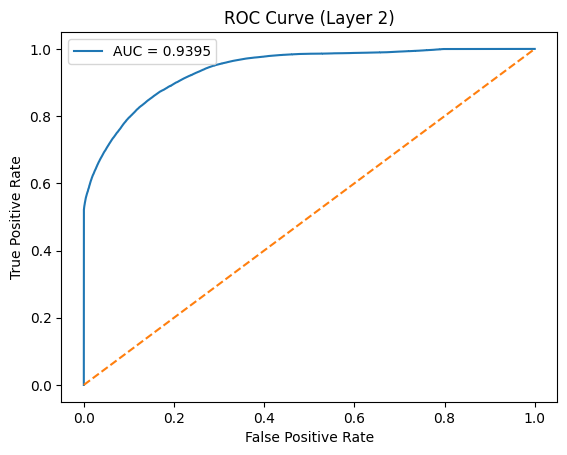

In [17]:
# =========================================
# 📈 ROC CURVE + AUC (Layer 2)
# =========================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities from Layer 2
meta_X_test = np.hstack([X_test, get_layer1_probs(X_test)])
y_scores = meta_model.predict_proba(meta_X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Layer 2)")
plt.legend()
plt.show()

In [18]:
# =========================================
# 🎯 THRESHOLD TUNING
# =========================================

best_thresh = 0.5
best_f1 = 0

from sklearn.metrics import f1_score

for t in thresholds:
    preds = (y_scores > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F1:", best_f1)

# Save this globally
FINAL_THRESHOLD = best_thresh

Best Threshold: 0.3181881427593261
Best F1: 0.8556287429043312


In [19]:
# # =========================================
# # 🔥 AUTOENCODER (Layer 3 - Deep)
# # Train ONLY on benign
# # =========================================

# X_benign = X_train[y_train == 0]

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization

input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
x = Dense(128, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)

# Bottleneck
encoded = Dense(16, activation='relu')(x)

# Decoder
x = Dense(32, activation='relu')(encoded)
x = Dense(64, activation='relu')(x)
x = Dense(128, activation='relu')(x)
decoded = Dense(input_dim, activation='linear')(x)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train ONLY on benign
X_benign = X_train[y_train == 0]

autoencoder.fit(
    X_benign, X_benign,
    epochs=15,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

def get_recon_error(X):
    recon = autoencoder.predict(X, verbose=0)
    return np.mean((X - recon) ** 2, axis=1)

# # Proper threshold
# train_error = get_recon_error(X_benign)
# AE_THRESHOLD = np.mean(train_error) + 3*np.std(train_error)

train_error = get_recon_error(X_benign)

AE_THRESHOLD = np.percentile(train_error, 90)

print("AE Threshold:", AE_THRESHOLD)

2026-04-25 15:41:28.744128: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0479 - val_loss: 0.0061
Epoch 2/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0022 - val_loss: 4.5062e-04
Epoch 3/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0011 - val_loss: 3.8427e-04
Epoch 4/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 6.4054e-04 - val_loss: 1.6071e-04
Epoch 5/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 3.6410e-04 - val_loss: 8.5305e-04
Epoch 6/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.2535e-04 - val_loss: 3.3109e-04
Epoch 7/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2.8558e-04 - val_loss: 1.0577e-04
Epoch 8/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2.5728e-04 - val_loss: 3.2819e-04
Epoch 9/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.9280e-04 - val_loss: 0.0012
Epoch 10/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2.5527e-04 - val_loss: 7.4413e-04
Epoch 11/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - lo

In [20]:
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed

timesteps = 1  # since tabular, keep 1
features = X_train.shape[1]

X_lstm = X_train.reshape((X_train.shape[0], timesteps, features))

input_layer = Input(shape=(timesteps, features))

encoded = LSTM(64, activation='relu')(input_layer)
encoded = RepeatVector(timesteps)(encoded)

decoded = LSTM(64, activation='relu', return_sequences=True)(encoded)
decoded = TimeDistributed(Dense(features))(decoded)

lstm_autoencoder = Model(input_layer, decoded)
lstm_autoencoder.compile(optimizer='adam', loss='mse')

lstm_autoencoder.fit(X_lstm, X_lstm, epochs=10, batch_size=256)

Epoch 1/10
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0842
Epoch 2/10
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 1.1192e-05
Epoch 3/10
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 6.5937e-07
Epoch 4/10
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 6.1863e-07
Epoch 5/10
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 9.0342e-07
Epoch 6/10
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 1.4109e-06
Epoch 7/10
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 1.0739e-06
Epoch 8/10
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 1.0112e-06
Epoch 9/10
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 1.0717e-06
Epoch 10/10
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 9.9948e-07


In [21]:
# =========================================
# 🌲 ISOLATION FOREST (Layer 3 - Statistical)
# =========================================

# iso = IsolationForest(contamination=0.01)
# iso.fit(X_train)

iso = IsolationForest(contamination=0.005)
iso.fit(X_benign)

IsolationForest(contamination=0.005)

In [22]:
def get_recon_error(X):
    recon = autoencoder.predict(X, verbose=0)
    return np.mean((X - recon) ** 2, axis=1)


def get_anomaly_flag(X):
    recon_error = get_recon_error(X)
    iso_pred = iso.predict(X)

    return (recon_error > AE_THRESHOLD) & (iso_pred == -1)

In [23]:
def predict_layer1(X):

    rf_p = rf.predict_proba(X)
    xgb_p = xgb.predict_proba(X)
    lgbm_p = lgbm.predict_proba(X)
    et_p = et.predict_proba(X)

    # Weighted ensemble (IMPORTANT FIX)
    probs = (
        0.3 * rf_p +
        0.3 * xgb_p +
        0.3 * lgbm_p +
        0.1 * et_p
    )

    return np.argmax(probs, axis=1)

In [24]:
def predict_layer2(X):

    meta_X = np.hstack([X, get_layer1_probs(X)])
    probs = meta_model.predict_proba(meta_X)[:,1]

    return (probs > FINAL_THRESHOLD).astype(int)

In [25]:
def predict_layer3(X):
    return get_anomaly_flag(X).astype(int)

In [26]:
def predict_layer12(X):
    return predict_layer2(X)

In [27]:
LOW_THRESHOLD = FINAL_THRESHOLD / 2
HIGH_THRESHOLD = FINAL_THRESHOLD

def predict_full(X):

    meta_X = np.hstack([X, get_layer1_probs(X)])
    probs = meta_model.predict_proba(meta_X)[:,1]

    anomaly_flag = get_anomaly_flag(X)

    final = []

    for i in range(len(X)):

        # ✅ High confidence attack
        if probs[i] > FINAL_THRESHOLD:
            final.append(1)

        # ✅ High confidence benign
        elif probs[i] < LOW_THRESHOLD:
            final.append(0)

        # ⚠️ Uncertain → use anomaly detection
        else:
            if anomaly_flag[i]:
                final.append(1)
            else:
                final.append(0)

    return np.array(final)

In [28]:
from sklearn.metrics import classification_report, accuracy_score

def evaluate(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))


# Run all
evaluate("Layer 1", y_test, predict_layer1(X_test))
evaluate("Layer 2", y_test, predict_layer2(X_test))
evaluate("Layer 3", y_test, predict_layer3(X_test))
evaluate("Layer 1 + 2", y_test, predict_layer12(X_test))
evaluate("Full Pipeline (L1+L2+L3)", y_test, predict_full(X_test))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Layer 1 ===
              precision    recall  f1-score   support

           0       0.86      0.79      0.83     72850
           1       0.81      0.87      0.84     73111

    accuracy                           0.83    145961
   macro avg       0.83      0.83      0.83    145961
weighted avg       0.83      0.83      0.83    145961

Accuracy: 0.8318180883934749


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Layer 2 ===
              precision    recall  f1-score   support

           0       0.89      0.80      0.84     72850
           1       0.82      0.90      0.86     73111

    accuracy                           0.85    145961
   macro avg       0.85      0.85      0.85    145961
weighted avg       0.85      0.85      0.85    145961

Accuracy: 0.8478840238145806

=== Layer 3 ===
              precision    recall  f1-score   support

           0       0.50      0.99      0.66     72850
           1       0.00      0.00      0.00     73111

    accuracy                           0.50    145961
   macro avg       0.25      0.50      0.33    145961
weighted avg       0.25      0.50      0.33    145961

Accuracy: 0.49637231863305953


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Layer 1 + 2 ===
              precision    recall  f1-score   support

           0       0.89      0.80      0.84     72850
           1       0.82      0.90      0.86     73111

    accuracy                           0.85    145961
   macro avg       0.85      0.85      0.85    145961
weighted avg       0.85      0.85      0.85    145961

Accuracy: 0.8478840238145806


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Full Pipeline (L1+L2+L3) ===
              precision    recall  f1-score   support

           0       0.89      0.80      0.84     72850
           1       0.82      0.90      0.86     73111

    accuracy                           0.85    145961
   macro avg       0.85      0.85      0.85    145961
weighted avg       0.85      0.85      0.85    145961

Accuracy: 0.8478840238145806


In [29]:
# =========================================
# 🧪 FINAL ATTACK PREDICTOR
# =========================================

def predict_attack_type(X_input):

    probs = get_attack_model_probs(X_input)
    meta_X = np.hstack([X_input, probs])

    preds = attack_meta_model.predict(meta_X)

    return [ATTACK_CLASS_NAMES[p] for p in preds]


# Example
print("\n🔮 Sample Attack Predictions:")
print(predict_attack_type(X_attack_test[:10]))


🔮 Sample Attack Predictions:
['Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'DDOS attack-HOIC', 'Benign']


In [30]:
def full_ids_pipeline(X):

    binary_pred = predict_full(X)   # your old pipeline

    final = []

    for i in range(len(X)):

        if binary_pred[i] == 0:
            final.append("BENIGN")

        else:
            attack = predict_attack_type(X[i:i+1])[0]
            final.append(attack)

    return final


🎯 Attack Classification Accuracy: 0.8628937215447406

📊 Classification Report:

                          precision    recall  f1-score   support

                  Benign       0.90      0.97      0.93    133853
                     Bot       0.00      0.00      0.00      2834
        DDOS attack-HOIC       0.85      0.89      0.87      6824
    DDOS attack-LOIC-UDP       0.71      0.36      0.48        14
  DDoS attacks-LOIC-HTTP       0.32      0.19      0.24      5741
   DoS attacks-GoldenEye       0.65      0.27      0.38       412
        DoS attacks-Hulk       0.57      0.02      0.03      4591
DoS attacks-SlowHTTPTest       0.00      0.00      0.00      1390
   DoS attacks-Slowloris       0.16      0.68      0.26       111
          FTP-BruteForce       0.41      0.99      0.58      1953
           Infilteration       0.02      0.00      0.00      1611
          SSH-Bruteforce       0.00      0.00      0.00      1884

                accuracy                           0.86    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


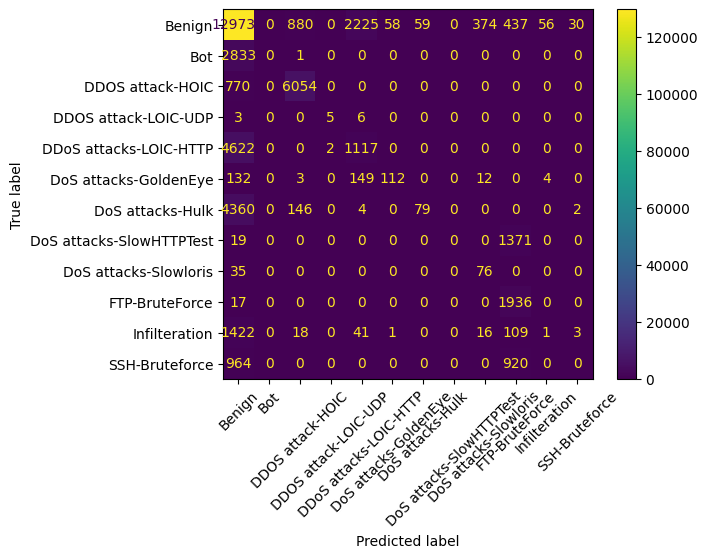

In [31]:
# =========================================
# 📊 ATTACK METRICS (SAFE VERSION)
# =========================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 🔥 Generate predictions (always recompute)
attack_meta_X_test = np.hstack([
    X_attack_test,
    get_attack_model_probs(X_attack_test)
])

attack_preds = attack_meta_model.predict(attack_meta_X_test)

# ✅ Accuracy
acc = accuracy_score(y_attack_test, attack_preds)

print("\n🎯 Attack Classification Accuracy:", acc)

# ✅ Classification report
print("\n📊 Classification Report:\n")
print(classification_report(
    y_attack_test,
    attack_preds,
    target_names=ATTACK_CLASS_NAMES
))

# ✅ Confusion Matrix
cm = confusion_matrix(y_attack_test, attack_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ATTACK_CLASS_NAMES)
disp.plot(xticks_rotation=45)

In [32]:
# =========================================
# 📈 ROC / AUC (MULTI-CLASS)
# =========================================

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Probabilities
attack_probs_test = attack_meta_model.predict_proba(attack_meta_X_test)

# One-vs-rest encoding
y_test_bin = label_binarize(y_attack_test, classes=np.arange(len(ATTACK_CLASS_NAMES)))

auc = roc_auc_score(y_test_bin, attack_probs_test, average='macro', multi_class='ovr')

print("\n📈 Macro AUC Score:", auc)


📈 Macro AUC Score: 0.9101602606984859


In [33]:
# =========================================
# 🔍 SAMPLE PREDICTIONS (SAFE)
# =========================================

# Recompute predictions
attack_meta_X_test = np.hstack([
    X_attack_test,
    get_attack_model_probs(X_attack_test)
])

attack_preds = attack_meta_model.predict(attack_meta_X_test)

# Pick attack samples (exclude BENIGN)
attack_only_idx = [
    i for i, y in enumerate(y_attack_test)
    if ATTACK_CLASS_NAMES[y] != "Benign"
]

sample_idx = attack_only_idx[:20]

X_sample = X_attack_test.iloc[sample_idx]
y_true_sample = y_attack_test.iloc[sample_idx]

y_pred_sample = attack_meta_model.predict(
    np.hstack([X_sample, get_attack_model_probs(X_sample)])
)

print("\n🔎 Sample Predictions:\n")

for i in range(len(sample_idx)):
    print(f"Sample {i}")
    print("Actual   :", ATTACK_CLASS_NAMES[y_true_sample.iloc[i]])
    print("Predicted:", ATTACK_CLASS_NAMES[y_pred_sample[i]])
    print("-"*40)


🔎 Sample Predictions:

Sample 0
Actual   : DDOS attack-HOIC
Predicted: DDOS attack-HOIC
----------------------------------------
Sample 1
Actual   : DDoS attacks-LOIC-HTTP
Predicted: Benign
----------------------------------------
Sample 2
Actual   : DDoS attacks-LOIC-HTTP
Predicted: Benign
----------------------------------------
Sample 3
Actual   : DDoS attacks-LOIC-HTTP
Predicted: Benign
----------------------------------------
Sample 4
Actual   : DoS attacks-Hulk
Predicted: Benign
----------------------------------------
Sample 5
Actual   : DDoS attacks-LOIC-HTTP
Predicted: Benign
----------------------------------------
Sample 6
Actual   : DDOS attack-HOIC
Predicted: DDOS attack-HOIC
----------------------------------------
Sample 7
Actual   : SSH-Bruteforce
Predicted: FTP-BruteForce
----------------------------------------
Sample 8
Actual   : Bot
Predicted: Benign
----------------------------------------
Sample 9
Actual   : DoS attacks-SlowHTTPTest
Predicted: FTP-BruteForce
----

In [34]:
# =========================================
# 🧠 MULTI-SAMPLE EXPLAINABILITY (CLEAN)
# =========================================

import shap
import numpy as np

# Use trained RF model
explainer = shap.TreeExplainer(rf_attack)

# ✅ Align features EXACTLY
X_explain = X_attack_test.copy()
X_explain = X_explain[X_attack_train.columns]

# Select samples (first 15 attack samples)
num_samples = 50

X_sample = X_explain.iloc[:num_samples]
y_true_sample = y_attack_test.iloc[:num_samples]

# Predictions
y_pred_sample = rf_attack.predict(X_sample)

# SHAP values
shap_values = explainer.shap_values(X_sample)

print("\n🔍 EXPLAINING MULTIPLE SAMPLES:\n")

for i in range(num_samples):

    print("="*60)
    print(f"Sample {i}")

    actual_label = ATTACK_CLASS_NAMES[y_true_sample.iloc[i]]
    predicted_label = ATTACK_CLASS_NAMES[y_pred_sample[i]]

    print("Actual    :", actual_label)
    print("Predicted :", predicted_label)

    pred_class = y_pred_sample[i]

    # Get SHAP values for that class
    shap_vals = shap_values[pred_class][i]
    feature_vals = X_sample.iloc[i]

    # Get top contributing features
    top_idx = np.argsort(np.abs(shap_vals))[-5:][::-1]

    print("\nTop 5 contributing features:")

    for idx in top_idx:
        feature_name = X_sample.columns[idx]
        contribution = shap_vals[idx]
        value = feature_vals.iloc[idx]

        direction = "↑ increases" if contribution > 0 else "↓ decreases"

        print(f"{feature_name} = {value:.3f} | {direction} attack score ({contribution:.4f})")

    print("="*60)


🔍 EXPLAINING MULTIPLE SAMPLES:

Sample 0
Actual    : Benign
Predicted : Benign

Top 5 contributing features:
Dst Port = 50081.000 | ↑ increases attack score (0.2481)
TotLen Fwd Pkts = 0.000 | ↓ decreases attack score (-0.0570)
Fwd Pkt Len Mean = 0.000 | ↓ decreases attack score (-0.0556)
Timestamp = 0.000 | ↓ decreases attack score (-0.0275)
Tot Fwd Pkts = 2.000 | ↓ decreases attack score (-0.0227)
Sample 1
Actual    : Benign
Predicted : Benign

Top 5 contributing features:
Flow Duration = 636.000 | ↓ decreases attack score (-0.0010)
Dst Port = 80.000 | ↑ increases attack score (0.0003)
Fwd Pkt Len Mean = 53.667 | ↓ decreases attack score (-0.0002)
Protocol = 6.000 | ↑ increases attack score (0.0002)
Fwd Pkt Len Max = 161.000 | ↑ increases attack score (0.0002)
Sample 2
Actual    : Benign
Predicted : Benign

Top 5 contributing features:
Fwd Pkt Len Std = 0.000 | ↓ decreases attack score (0.0000)
Fwd Pkt Len Mean = 38.000 | ↓ decreases attack score (0.0000)
Fwd Pkt Len Min = 38.000 | ↓

In [43]:
# =========================================
# 🧠 ONE SAMPLE PER CLASS (FINAL ROBUST FIX)
# =========================================

import shap
import numpy as np
import pandas as pd

explainer = shap.TreeExplainer(rf_attack)

X_explain = X_attack_test.copy()
X_explain = X_explain[X_attack_train.columns]

y_pred_all = rf_attack.predict(X_explain)

# pick one sample per TRUE class
selected_indices = []
seen = set()

for i in range(len(y_attack_test)):
    cls = y_attack_test.iloc[i]
    if cls not in seen:
        selected_indices.append(i)
        seen.add(cls)
    if len(seen) == len(ATTACK_CLASS_NAMES):
        break

selected_indices = selected_indices[:10]

X_small = X_explain.iloc[selected_indices].reset_index(drop=True)
y_true_small = y_attack_test.iloc[selected_indices].reset_index(drop=True)

y_pred_small = rf_attack.predict(X_small)

shap_values = explainer.shap_values(X_small)

print("\n🔍 ONE SAMPLE PER CLASS (UP TO 10):\n")

for i in range(len(X_small)):

    class_id = y_pred_small[i]
    class_name = ATTACK_CLASS_NAMES[class_id]

    print("=" * 70)
    print(f"🎯 Class: {class_name}")

    print("Actual    :", ATTACK_CLASS_NAMES[y_true_small.iloc[i]])
    print("Predicted :", class_name)

    # =========================================
    # 🔥 SAFE SHAP HANDLING (AUTO DETECT SHAPE)
    # =========================================

    sv = shap_values

    # CASE 1: list format (old SHAP)
    if isinstance(sv, list):
        shap_vals = sv[class_id][i]

    else:
        sv = np.array(sv)

        # detect layout
        if sv.ndim == 3:

            # try sample-first layout
            if sv.shape[0] == len(X_small):
                # (samples, features, classes) OR (samples, classes, features)

                if sv.shape[2] == len(ATTACK_CLASS_NAMES):
                    # (sample, feature, class)
                    shap_vals = sv[i, :, class_id]

                else:
                    # (sample, class, feature)
                    shap_vals = sv[i, class_id, :]

            else:
                # fallback (class-first)
                shap_vals = sv[class_id, i, :]

        else:
            raise ValueError("Unexpected SHAP shape: " + str(sv.shape))

    feature_vals = X_small.iloc[i]

    top_idx = np.argsort(np.abs(shap_vals))[-5:][::-1]

    print("\nTop reasons for this prediction:")

    for f in top_idx:

        direction = "↑ increases attack likelihood" if shap_vals[f] > 0 else "↓ reduces attack likelihood"

        print(
            f"• {X_small.columns[f]} = {feature_vals.iloc[f]:.2f}\n"
            f"   → {direction} ({shap_vals[f]:.4f})"
        )

    print("=" * 70)


🔍 ONE SAMPLE PER CLASS (UP TO 10):

🎯 Class: Benign
Actual    : Benign
Predicted : Benign

Top reasons for this prediction:
• Dst Port = 50081.00
   → ↑ increases attack likelihood (0.2481)
• Init Fwd Win Byts = 131.00
   → ↑ increases attack likelihood (0.0979)
• Fwd Seg Size Min = 20.00
   → ↑ increases attack likelihood (0.0817)
• Flow IAT Min = 92.00
   → ↑ increases attack likelihood (0.0337)
• Flow IAT Mean = 92.00
   → ↑ increases attack likelihood (0.0335)
🎯 Class: DDOS attack-HOIC
Actual    : DDOS attack-HOIC
Predicted : DDOS attack-HOIC

Top reasons for this prediction:
• Init Fwd Win Byts = 32738.00
   → ↑ increases attack likelihood (0.3129)
• Fwd Seg Size Min = 20.00
   → ↑ increases attack likelihood (0.0936)
• Dst Port = 80.00
   → ↑ increases attack likelihood (0.0575)
• Fwd Header Len = 40.00
   → ↑ increases attack likelihood (0.0475)
• Flow Duration = 6084.00
   → ↑ increases attack likelihood (0.0467)
🎯 Class: DDoS attacks-LOIC-HTTP
Actual    : DDoS attacks-LOIC-HT